# 03 · Recurrent Models: GRU vs LSTM vs BiLSTM

**DeepCodeGuard** · Week 3

TF-IDF treated code as a **bag of tokens**: `free(p); use(p);` and `use(p); free(p);` looked identical, even though only one is a use-after-free. Recurrent neural networks read code **in order**, one token at a time, carrying a memory (the *hidden state*) of what came before.

We compare three architectures with everything else held equal:

| Model | Idea |
|---|---|
| **GRU** | Gated recurrent unit: 2 gates (update, reset) decide what to keep in memory |
| **LSTM** | Long short-term memory: 3 gates + a separate cell state, designed for longer dependencies |
| **BiLSTM** | Two LSTMs, one reading left→right and one right→left, so each position sees context on both sides |

**Research questions** (from the spec):
- *Experiment 1*: Do learned sequential representations beat TF-IDF?
- *Experiment 2*: Does LSTM's extra memory help compared with GRU?

Each model is trained with **3 random seeds**, and we report mean ± standard deviation. Differences smaller than the std are noise, not real improvements.

> ⚙️ **Before running:** Runtime → Change runtime type → **T4 GPU**. The full run (3 models × 3 seeds) takes roughly 30–45 minutes. Keep the tab open, and wait for the final table before saving to GitHub.

## 0 · Setup

In [12]:
!git clone -q https://github.com/reenupalle/deepcodeguard.git 2>/dev/null || (cd deepcodeguard && git pull -q)
%cd /content/deepcodeguard
!pip install -q datasets
!python src/deepcodeguard/data/download.py

/content/deepcodeguard
Creating json from Arrow format: 100% 22/22 [00:00<00:00, 29.38ba/s]
train        21854 rows  OK
            labels   {0: 11836, 1: 10018}
            projects {'FFmpeg': 7822, 'qemu': 14032}
Creating json from Arrow format: 100% 3/3 [00:00<00:00, 34.82ba/s]
validation    2732 rows  OK
            labels   {1: 1187, 0: 1545}
            projects {'qemu': 1761, 'FFmpeg': 971}
Creating json from Arrow format: 100% 3/3 [00:00<00:00, 33.59ba/s]
test          2732 rows  OK
            labels   {0: 1477, 1: 1255}
            projects {'FFmpeg': 976, 'qemu': 1756}
columns: ['id', 'func', 'target', 'project', 'commit_id']


## 1 · Configuration
All hyperparameters live in one place so the report can list them exactly. To do a quick test run first, set `SEEDS = [42]` and `MAX_EPOCHS = 2`.

In [13]:
import sys
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "src")
from deepcodeguard.evaluation.metrics import val_then_test   # shared with every notebook

CONFIG = {
    "max_len": 512,          # tokens kept per function (longer ones are cut)
    "min_freq": 3,           # tokens seen fewer times in train become <unk>
    "max_vocab": 30_000,
    "embedding_dim": 128,
    "hidden_dim": 128,
    "num_layers": 1,
    "dropout": 0.3,
    "batch_size": 64,
    "lr": 1e-3,
    "max_epochs": 10,
    "patience": 2,           # early stopping: epochs without val ROC-AUC improvement
    "grad_clip": 1.0,
}
SEEDS = [42, 43, 44]
MODELS = {   # name: (cell type, bidirectional)
    "GRU": ("gru", False),
    "LSTM": ("lstm", False),
    "BiLSTM": ("lstm", True),
}
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 2 · Load data

In [14]:
data = {s: pd.read_json(f"data/raw/{s}.jsonl", lines=True) for s in ["train", "validation", "test"]}
y = {s: d["target"].astype(int).values for s, d in data.items()}
for s, d in data.items():
    print(f"{s:<11} {len(d):>6} rows")

train        21854 rows
validation    2732 rows
test          2732 rows


## 3 · Tokenise and build the vocabulary
Each function becomes a list of tokens (identifiers, numbers, symbols), then a list of integer IDs.

- The **vocabulary** is built from **train only**: the most frequent tokens, each seen at least `min_freq` times.
- Unknown or rare tokens map to `<unk>` (ID 1). Padding uses `<pad>` (ID 0).
- Functions longer than `max_len` are **truncated** (we keep the beginning). The EDA showed the median function is ~208 tokens, so most functions fit completely.

In [15]:
import re

TOKEN_RE = re.compile(r"[A-Za-z_]\w*|\d+|\S")   # same tokeniser as the baselines
PAD, UNK = 0, 1

tokens = {s: [TOKEN_RE.findall(code) for code in d["func"]] for s, d in data.items()}
counts = Counter(t for toks in tokens["train"] for t in toks)
vocab = ["<pad>", "<unk>"] + [t for t, c in counts.most_common(CONFIG["max_vocab"]) if c >= CONFIG["min_freq"]]
stoi = {t: i for i, t in enumerate(vocab)}
print(f"Vocabulary size: {len(vocab):,}")


def encode(toks):
    ids = [stoi.get(t, UNK) for t in toks[:CONFIG["max_len"]]]
    return ids + [PAD] * (CONFIG["max_len"] - len(ids)), max(len(ids), 1)


def make_dataset(split):
    ids, lengths = zip(*(encode(t) for t in tokens[split]))
    return TensorDataset(torch.tensor(ids), torch.tensor(lengths), torch.tensor(y[split], dtype=torch.float32))


datasets = {s: make_dataset(s) for s in data}
truncated = np.mean([len(t) > CONFIG["max_len"] for t in tokens["train"]])
unk_rate = np.mean([stoi.get(t, UNK) == UNK for toks in tokens["validation"] for t in toks[:CONFIG["max_len"]]])
print(f"Train functions truncated at {CONFIG['max_len']} tokens: {100 * truncated:.1f}%")
print(f"Validation tokens that are <unk>: {100 * unk_rate:.1f}%")
print("Example:", tokens["train"][0][:12], "→", datasets["train"][0][0][:12].tolist())

Vocabulary size: 30,002
Train functions truncated at 512 tokens: 23.2%
Validation tokens that are <unk>: 4.6%
Example: ['static', 'av_cold', 'int', 'vdadec_init', '(', 'AVCodecContext', '*', 'avctx', ')', '{', 'VDADecoderContext', '*'] → [51, 766, 28, 1, 4, 249, 9, 38, 3, 13, 1, 9]


## 4 · The model
One class covers all three architectures:

`token IDs → Embedding → GRU / LSTM / BiLSTM → final hidden state → Dropout → Dense → P(vulnerable)`

- The **embedding** layer learns a vector for every token, so similar tokens end up close together.
- `pack_padded_sequence` tells the RNN each function's true length, so padding doesn't affect the final hidden state.
- For the BiLSTM we concatenate the last forward state and the last backward state.

In [16]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, cell="lstm", bidirectional=False, embedding_dim=128,
                 hidden_dim=128, num_layers=1, dropout=0.3, **_):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD)
        rnn_cls = nn.GRU if cell == "gru" else nn.LSTM
        self.rnn = rnn_cls(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True,
                           bidirectional=bidirectional, dropout=dropout if num_layers > 1 else 0.0)
        self.bidirectional = bidirectional
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_dim * (2 if bidirectional else 1), 1)

    def forward(self, ids, lengths):
        packed = pack_padded_sequence(self.embedding(ids), lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)
        if isinstance(hidden, tuple):        # LSTM returns (hidden state, cell state)
            hidden = hidden[0]
        last = torch.cat([hidden[-2], hidden[-1]], dim=1) if self.bidirectional else hidden[-1]
        return self.head(self.dropout(last)).squeeze(-1)


for name, (cell, bi) in MODELS.items():
    m = RNNClassifier(len(vocab), cell, bi, **CONFIG)
    print(f"{name:<7} parameters: {sum(p.numel() for p in m.parameters()):,}")

GRU     parameters: 3,939,457
LSTM    parameters: 3,972,481
BiLSTM  parameters: 4,104,705


## 5 · Training loop
- **Loss**: binary cross-entropy. **Optimiser**: Adam.
- **Gradient clipping** caps the gradient size. RNNs multiply gradients across hundreds of time steps, and without it they can "explode".
- **Early stopping** on validation ROC-AUC, keeping the best weights.
- After training, the decision **threshold is tuned on validation**, then test is evaluated **once**.

In [17]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def predict(model, split):
    model.eval()
    out = []
    with torch.no_grad():
        for ids, lengths, _ in DataLoader(datasets[split], batch_size=256):
            out.append(torch.sigmoid(model(ids.to(device), lengths)).cpu().numpy())
    return np.concatenate(out)


def train_one(name, seed):
    from sklearn.metrics import roc_auc_score
    set_seed(seed)
    cell, bi = MODELS[name]
    model = RNNClassifier(len(vocab), cell, bi, **CONFIG).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
    loss_fn = nn.BCEWithLogitsLoss()
    loader = DataLoader(datasets["train"], batch_size=CONFIG["batch_size"], shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    best_auc, best_state, bad, history = 0.0, None, 0, []
    start = time.time()
    for epoch in range(1, CONFIG["max_epochs"] + 1):
        model.train()
        total = 0.0
        for ids, lengths, target in loader:
            opt.zero_grad()
            loss = loss_fn(model(ids.to(device), lengths), target.to(device))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
            opt.step()
            total += loss.item() * len(target)
        val_auc = roc_auc_score(y["validation"], predict(model, "validation"))
        history.append({"model": name, "seed": seed, "epoch": epoch,
                        "train_loss": total / len(datasets["train"]), "val_roc_auc": val_auc})
        print(f"  epoch {epoch:>2}  loss {history[-1]['train_loss']:.4f}  val ROC-AUC {val_auc:.4f}")
        if val_auc > best_auc:
            best_auc, bad = val_auc, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= CONFIG["patience"]:
                break
    model.load_state_dict(best_state)
    t, val, test = val_then_test(y["validation"], predict(model, "validation"),
                                 y["test"], predict(model, "test"))
    row = {"model": name, "seed": seed, "threshold": round(t, 2), "best_epoch": int(np.argmax([h["val_roc_auc"] for h in history if h["seed"] == seed]) + 1),
           "train_minutes": round((time.time() - start) / 60, 1), "val_f1": val["f1"],
           **{f"test_{k}": v for k, v in test.items()}}
    print(f"  → test F1 {test['f1']:.3f}  ROC-AUC {test['roc_auc']:.3f}  (threshold {t:.2f})")
    return row, history

## 6 · Run all experiments
3 models × 3 seeds = 9 training runs. Progress prints as it goes.

In [9]:
RUNS, HISTORY = [], []
for name in MODELS:
    for seed in SEEDS:
        print(f"\n=== {name}  seed {seed} ===")
        row, hist = train_one(name, seed)
        RUNS.append(row)
        HISTORY.extend(hist)

runs = pd.DataFrame(RUNS)
Path("reports/tables").mkdir(parents=True, exist_ok=True)
runs.to_csv("reports/tables/rnn_runs.csv", index=False)
runs.round(3)


=== GRU  seed 42 ===
  epoch  1  loss 0.6843  val ROC-AUC 0.5681
  epoch  2  loss 0.6694  val ROC-AUC 0.5954
  epoch  3  loss 0.6357  val ROC-AUC 0.6240
  epoch  4  loss 0.5835  val ROC-AUC 0.6326
  epoch  5  loss 0.5240  val ROC-AUC 0.6367
  epoch  6  loss 0.4609  val ROC-AUC 0.6387
  epoch  7  loss 0.3987  val ROC-AUC 0.6400
  epoch  8  loss 0.3415  val ROC-AUC 0.6396
  epoch  9  loss 0.2918  val ROC-AUC 0.6440
  epoch 10  loss 0.2511  val ROC-AUC 0.6434
  → test F1 0.627  ROC-AUC 0.621  (threshold 0.09)

=== GRU  seed 43 ===
  epoch  1  loss 0.6831  val ROC-AUC 0.5649
  epoch  2  loss 0.6699  val ROC-AUC 0.5985
  epoch  3  loss 0.6361  val ROC-AUC 0.6156
  epoch  4  loss 0.5809  val ROC-AUC 0.6442
  epoch  5  loss 0.5133  val ROC-AUC 0.6475
  epoch  6  loss 0.4453  val ROC-AUC 0.6550
  epoch  7  loss 0.3783  val ROC-AUC 0.6501
  epoch  8  loss 0.3207  val ROC-AUC 0.6523
  → test F1 0.649  ROC-AUC 0.632  (threshold 0.10)

=== GRU  seed 44 ===
  epoch  1  loss 0.6855  val ROC-AUC 0.5

,model,seed,threshold,best_epoch,train_minutes,val_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,GRU,42,0.09,9,1.5,0.625,0.548,0.505,0.828,0.627,0.621,0.581
1,GRU,43,0.10,6,1.2,0.635,0.546,0.503,0.913,0.649,0.632,0.586
2,GRU,44,0.16,6,1.2,0.626,0.556,0.510,0.868,0.642,0.635,0.596
3,LSTM,42,0.06,10,1.5,0.615,0.544,0.502,0.837,0.628,0.611,0.558
4,LSTM,43,0.07,6,1.2,0.630,0.523,0.490,0.941,0.644,0.625,0.572
5,LSTM,44,0.07,8,1.5,0.622,0.548,0.504,0.861,0.636,0.626,0.579
6,BiLSTM,42,0.23,4,1.4,0.640,0.552,0.507,0.918,0.653,0.644,0.601
7,BiLSTM,43,0.15,4,1.4,0.641,0.531,0.495,0.955,0.652,0.649,0.602
8,BiLSTM,44,0.20,5,1.7,0.640,0.557,0.510,0.876,0.645,0.653,0.617


## 7 · Results: mean ± std over seeds, next to the baselines
Baseline numbers are copied from notebook 02 (same test set, same threshold protocol).

In [10]:
metrics = ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc", "test_pr_auc"]
summary = runs.groupby("model", sort=False)[metrics].agg(["mean", "std"])
table = pd.DataFrame({m.replace("test_", ""): summary[(m, "mean")].map("{:.3f}".format) + " ± "
                      + summary[(m, "std")].map("{:.3f}".format) for m in metrics})

baselines = pd.DataFrame({   # notebook 02 results, single run
    "accuracy": ["0.459", "0.582", "0.578"], "precision": ["0.459", "0.527", "0.524"],
    "recall": ["1.000", "0.891", "0.908"], "f1": ["0.630", "0.662", "0.664"],
    "roc_auc": ["0.500", "0.684", "0.675"], "pr_auc": ["0.459", "0.639", "0.639"],
}, index=["Always vulnerable", "TF-IDF + LogReg", "TF-IDF + MLP"])
comparison = pd.concat([baselines, table])
comparison.to_csv("reports/tables/rnn_vs_baselines.csv")
comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
Always vulnerable,0.459,0.459,1.000,0.630,0.500,0.459
TF-IDF + LogReg,0.582,0.527,0.891,0.662,0.684,0.639
TF-IDF + MLP,0.578,0.524,0.908,0.664,0.675,0.639
GRU,0.550 ± 0.005,0.506 ± 0.003,0.870 ± 0.043,0.639 ± 0.011,0.629 ± 0.007,0.588 ± 0.008
LSTM,0.538 ± 0.013,0.499 ± 0.008,0.880 ± 0.054,0.636 ± 0.008,0.621 ± 0.008,0.569 ± 0.011
BiLSTM,0.547 ± 0.013,0.504 ± 0.008,0.916 ± 0.039,0.650 ± 0.004,0.649 ± 0.004,0.607 ± 0.009


## 8 · Learning curves
One line per seed. If validation ROC-AUC peaks early and then falls while training loss keeps dropping, the model is overfitting.

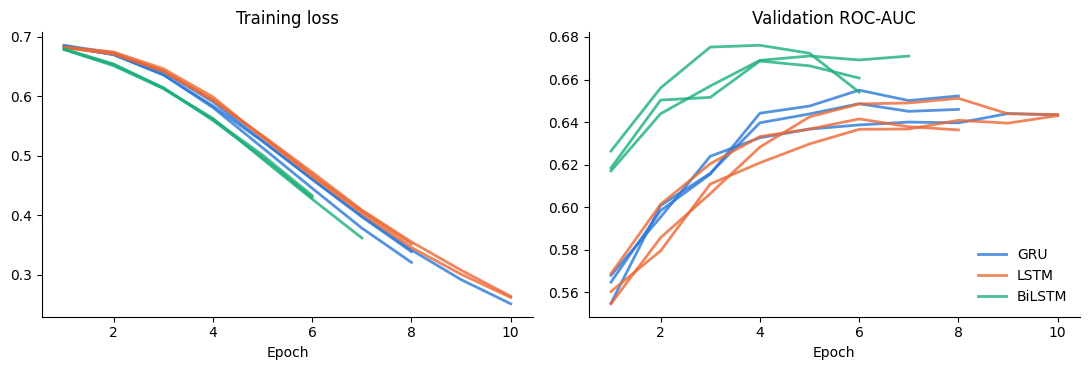

In [11]:
import matplotlib.pyplot as plt

hist = pd.DataFrame(HISTORY)
colors = {"GRU": "#2a78d6", "LSTM": "#eb6834", "BiLSTM": "#1baf7a"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for (name, seed), h in hist.groupby(["model", "seed"], sort=False):
    label = name if seed == SEEDS[0] else None
    axes[0].plot(h["epoch"], h["train_loss"], color=colors[name], linewidth=2, alpha=0.8, label=label)
    axes[1].plot(h["epoch"], h["val_roc_auc"], color=colors[name], linewidth=2, alpha=0.8, label=label)
axes[0].set_title("Training loss")
axes[1].set_title("Validation ROC-AUC")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.spines[["top", "right"]].set_visible(False)
axes[1].legend(frameon=False)
fig.tight_layout()
Path("reports/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("reports/figures/rnn_learning_curves.png", dpi=150)
plt.show()

## Findings
_Fill in after running:_
- _Experiment 1: do the RNNs beat TF-IDF on F1 and ROC-AUC, beyond the std?_
- _Experiment 2: GRU vs LSTM. Is the difference larger than the std across seeds?_
- _Does bidirectionality help?_
- _How many epochs until the best validation score, and is there overfitting?_